# Classification with Logistic Regression
**วัตถุประสงค์ช่วงบ่าย**
- อธิบายความแตกต่างระหว่าง Classification และ Regression
- สร้างโมเดล Binary Logistic Regression เพื่อจำแนก ผ่าน/ไม่ผ่าน
- แปลความหมาย Coefficient ในเชิงทิศทาง
- อ่านค่า Confusion Matrix, Accuracy, Precision และ Recall
- เข้าใจว่าทำไม Accuracy เพียงอย่างเดียวถึงหลอกตาได้

## เชื่อมโยงจากช่วงเช้า: Regression vs Classification

ช่วงเช้าเราทำนาย **ค่าต่อเนื่อง** (Continuous) เช่น จำนวนประชากร
ซึ่งเป็นตัวเลขที่บวกลบและเรียงลำดับได้ตามธรรมชาติ

ช่วงบ่ายนี้เราจะทำนาย **หมวดหมู่** (Category) เช่น ผ่าน / ไม่ผ่าน
ซึ่ง "label" เหล่านี้ไม่ใช่ตัวเลขที่บวกลบได้ ไม่สามารถพูดว่า "ไม่ผ่าน + ผ่าน = ?"

ทั้งคู่เป็น **Supervised Learning** เหมือนกัน คือมี label ให้โมเดลเรียน
- **Binary Classification**: 2 ระดับ เช่น ผ่าน/ไม่ผ่าน, สุขภาพดี/ป่วย
- **Multi-class Classification**: 3+ ระดับ เช่น ดี/พอใช้/เสื่อมโทรม

## Logistic Regression คืออะไร?

แม้ชื่อจะมีคำว่า "Regression" แต่ใช้สำหรับงาน **Classification**

หลักการ: แทนที่จะทำนายค่าตรง ๆ โมเดลจะแปลงผลลัพธ์ผ่าน **Sigmoid Function**
ซึ่งบีบทุกค่าให้อยู่ระหว่าง 0 ถึง 1 (ตีความเป็น probability)

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- ถ้า probability ≥ 0.5 → จัดเป็น class 1
- ถ้า probability < 0.5 → จัดเป็น class 0

โมเดลเรียนรู้ parameter ด้วยวิธี **Maximum Likelihood Estimation** ไม่ใช่ Least Squares

## ชุดข้อมูล: ดัชนีคุณภาพน้ำแหล่งน้ำผิวดิน (WQI)

**ที่มา:** กรมควบคุมมลพิษ
**ขนาด:** ~98 แถว (สถานีตรวจวัด × ไตรมาส)

**โจทย์ของเรา:** ทำนายว่าแหล่งน้ำ **ผ่าน** หรือ **ไม่ผ่าน** มาตรฐาน (WQI ≥ 61)

| Column | ความหมาย | หน่วย |
|--------|-----------|-------|
| DO | Dissolved Oxygen (ออกซิเจนละลายน้ำ) | mg/L |
| BCD | BOD — Biochemical Oxygen Demand (ความต้องการออกซิเจนทางชีวเคมี) | mg/L |
| NH3 | Ammonia Nitrogen (แอมโมเนียไนโตรเจน) | mg/L |
| target_binary | ผ่าน / ไม่ผ่าน | label |

**หมายเหตุ:** ชื่อคอลัมน์ในไฟล์คือ BCD แต่ในทางวิทยาศาสตร์เรียกว่า BOD
เราจะใช้ค่า StandardScaler เพราะ Feature ทั้ง 3 อยู่คนละ scale

In [1]:
# นำเข้า library หลักและโหลดข้อมูล
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wqi = pd.read_csv("wqi.csv", encoding="utf-8-sig")
wqi.head()

,ปี,ไตรมาส,แหล่งน้ำ,จุดตรวจวัด,BCD,DO,FCB,NH3,NO3,TCB,WQI,ระดับ,target_binary,target_multi
0,2560,1,แม่น้ำป่าสัก,PS04,3.9,3.2,4600.0,0.07,0.33,14000,60,เสื่อมโทรม,ไม่ผ่าน,เสื่อมโทรม
1,2560,1,แม่น้ำป่าสัก,PS05,2.3,5.0,490.0,0.02,0.35,2400,64,พอใช้,ผ่าน,พอใช้
2,2560,1,แม่น้ำป่าสัก,PS07,1.8,4.0,5400.0,0.01,0.37,16000,60,เสื่อมโทรม,ไม่ผ่าน,เสื่อมโทรม
3,2560,2,แม่น้ำป่าสัก,PS04,3.5,6.0,1400.0,0.11,0.33,16000,56,เสื่อมโทรม,ไม่ผ่าน,เสื่อมโทรม
4,2560,2,แม่น้ำป่าสัก,PS05,2.6,7.8,490.0,0.02,0.15,790,70,พอใช้,ผ่าน,พอใช้


## Data Exploration

In [2]:
# ตรวจสอบข้อมูลสถิติพื้นฐาน
wqi.describe()

,ปี,ไตรมาส,BCD,DO,FCB,NH3,NO3,TCB,WQI
count,98.000000,98.00000,98.000000,98.000000,97.000000,98.000000,94.000000,98.000000,98.000000
mean,2562.683673,2.44898,2.173469,5.915306,2053.515464,0.104388,0.336489,7496.214286,67.132653
std,1.808325,1.14083,1.066215,1.601118,3134.825627,0.103057,0.365074,17030.563252,11.133342
min,2560.000000,1.00000,1.000000,2.400000,20.000000,0.010000,0.010000,20.000000,47.000000
25%,2561.000000,1.00000,1.400000,4.925000,330.000000,0.042500,0.062500,790.000000,58.000000
50%,2563.000000,2.00000,1.800000,5.800000,790.000000,0.070000,0.250000,3500.000000,65.500000
75%,2564.000000,3.00000,2.700000,6.800000,2600.000000,0.125000,0.437500,9200.000000,71.500000
max,2566.000000,4.00000,7.300000,12.000000,22000.000000,0.560000,1.760000,160000.000000,91.000000


In [3]:
# ตรวจสอบประเภทข้อมูลและจำนวน non-null
wqi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ปี             98 non-null     int64  
 1   ไตรมาส         98 non-null     int64  
 2   แหล่งน้ำ       98 non-null     object 
 3   จุดตรวจวัด     98 non-null     object 
 4   BCD            98 non-null     float64
 5   DO             98 non-null     float64
 6   FCB            97 non-null     float64
 7   NH3            98 non-null     float64
 8   NO3            94 non-null     float64
 9   TCB            98 non-null     int64  
 10  WQI            98 non-null     int64  
 11  ระดับ          98 non-null     object 
 12  target_binary  98 non-null     object 
 13  target_multi   98 non-null     object 
dtypes: float64(5), int64(4), object(5)
memory usage: 10.8+ KB


In [4]:
# ตรวจสอบค่าว่างในแต่ละคอลัมน์
wqi.isnull().sum()

ปี               0
ไตรมาส           0
แหล่งน้ำ         0
จุดตรวจวัด       0
BCD              0
DO               0
FCB              1
NH3              0
NO3              4
TCB              0
WQI              0
ระดับ            0
target_binary    0
target_multi     0
dtype: int64

In [5]:
# ดูความสมดุลของ class ผ่าน/ไม่ผ่าน
wqi['target_binary'].value_counts()

target_binary
ผ่าน       65
ไม่ผ่าน    33
Name: count, dtype: int64

In [6]:
# แยก feature เป็น numerical / categorical เพื่อเตรียม visualization
numerical = ['DO', 'BCD', 'NH3']
categorical = ['target_binary', 'target_multi']

print("Numerical features:", numerical)
print("Categorical features:", categorical)

Numerical features: ['DO', 'BCD', 'NH3']
Categorical features: ['target_binary', 'target_multi']


In [7]:
# ดู scale ของ Feature ทั้งสาม ก่อนตัดสินใจทำ preprocessing
wqi[['DO', 'BCD', 'NH3']].describe()

,DO,BCD,NH3
count,98.000000,98.000000,98.000000
mean,5.915306,2.173469,0.104388
std,1.601118,1.066215,0.103057
min,2.400000,1.000000,0.010000
25%,4.925000,1.400000,0.042500
50%,5.800000,1.800000,0.070000
75%,6.800000,2.700000,0.125000
max,12.000000,7.300000,0.560000


## ทำไมต้องใช้ StandardScaler?

จากตาราง describe ข้างต้น จะเห็นว่า:
- **DO** อยู่ในช่วงประมาณ 2–12 mg/L
- **BCD (BOD)** อยู่ในช่วงประมาณ 1–10 mg/L
- **NH3** อยู่ในช่วงประมาณ 0.01–0.56 mg/L

ช่วงค่าต่างกันชัดเจน → ถ้าไม่ปรับ Scale โมเดลจะให้น้ำหนักกับ Feature ที่มีตัวเลขใหญ่กว่าโดยอัตโนมัติ
ซึ่งไม่ยุติธรรมทางสถิติ

**StandardScaler** แปลงแต่ละ Feature ให้มี Mean = 0 และ Std = 1
เราจะ fit Scaler เฉพาะบน Train Set เท่านั้น เพื่อไม่ให้ข้อมูล Test รั่วไหลเข้ามา

C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.t

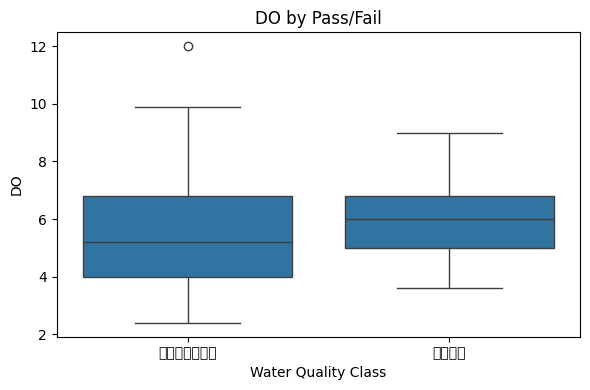

C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.t

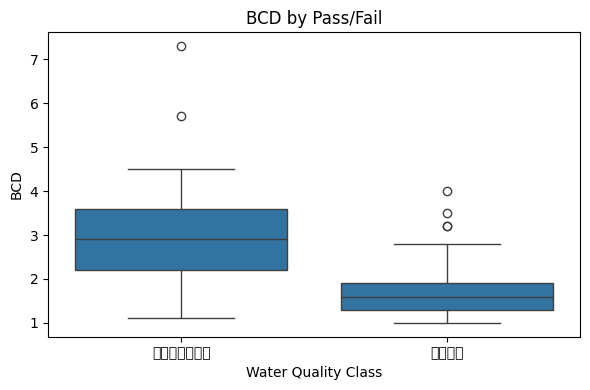

C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2411604983.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.t

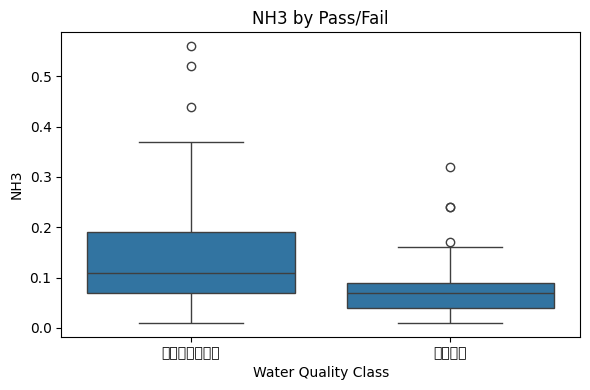

In [8]:
# วาด Boxplot เพื่อดูว่าแต่ละ Feature แยกผ่าน/ไม่ผ่านได้แค่ไหน
import matplotlib.pyplot as plt
import seaborn as sns

for feature in ['DO', 'BCD', 'NH3']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=wqi, x='target_binary', y=feature)
    plt.xlabel('Water Quality Class')
    plt.ylabel(feature)
    plt.title(f'{feature} by Pass/Fail')
    plt.tight_layout()
    plt.show()

## EDA เพิ่มเติม: Histogram แยกตาม class

C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.t

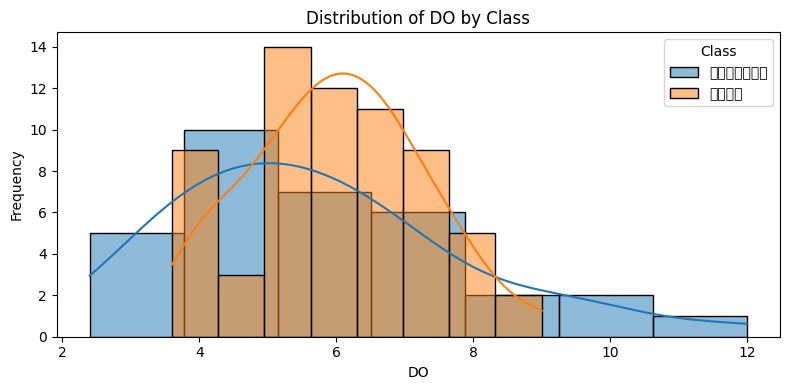

C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.t

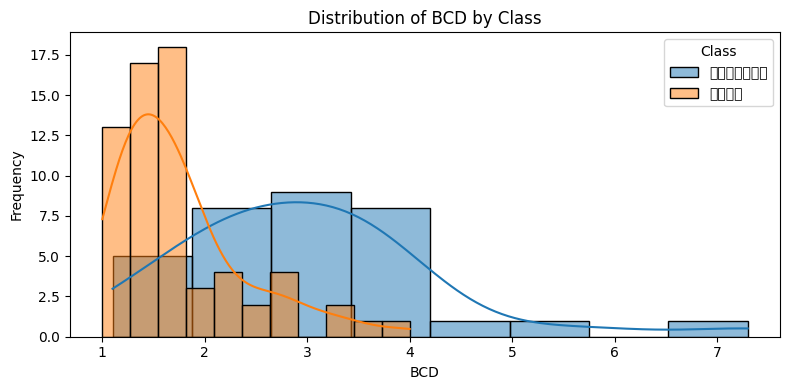

C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3206262995.py:11: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.t

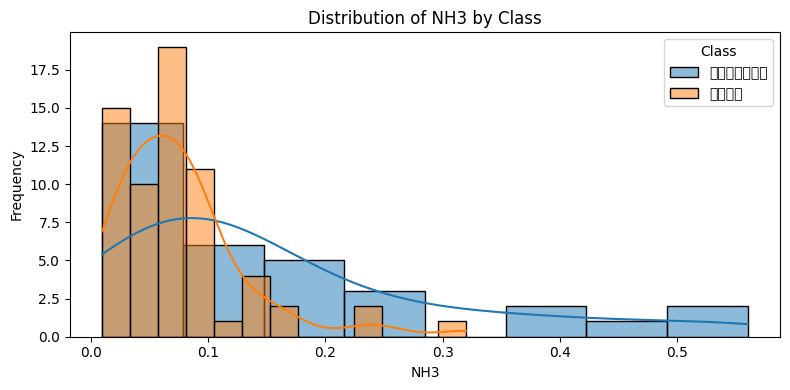

In [9]:
# Histogram / KDE ของแต่ละ feature แยกตาม target_binary
for feature in numerical:
    plt.figure(figsize=(8, 4))
    for cls in wqi['target_binary'].unique():
        sns.histplot(data=wqi[wqi['target_binary'] == cls],
                     x=feature, kde=True, label=cls, alpha=0.5)
    plt.title(f'Distribution of {feature} by Class')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_28492\2286828156.py:9: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2286828156.py:9: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2286828156.py:9: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2286828156.py:9: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2286828156.py:9: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\2286828156.py:9: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.tight_l

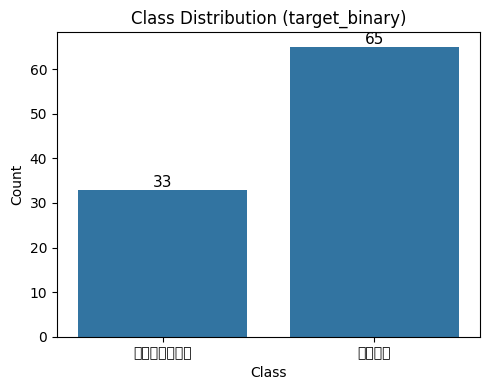

In [10]:
# Count plot ของ target
plt.figure(figsize=(5, 4))
ax = sns.countplot(x='target_binary', data=wqi)
for container in ax.containers:
    ax.bar_label(container, fontsize=11)
plt.title('Class Distribution (target_binary)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [11]:
# Grouped mean ของแต่ละ feature ตาม class
wqi.groupby('target_binary')[numerical].mean()

,DO,BCD,NH3
target_binary,,,
ผ่าน,5.998462,1.753846,0.076308
ไม่ผ่าน,5.751515,3.000000,0.159697


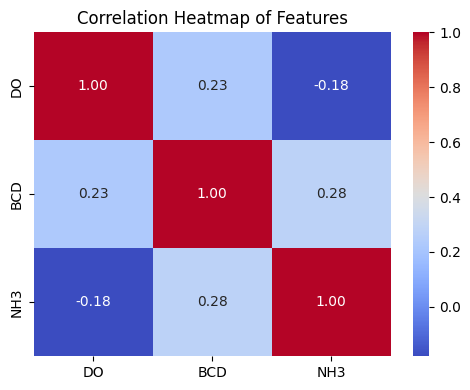

In [12]:
# Correlation heatmap ของ feature ตัวเลข
plt.figure(figsize=(5, 4))
sns.heatmap(wqi[numerical].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.tight_layout()
plt.show()

## สังเกตจาก Boxplot ก่อนเข้า Phase B

- **BCD (BOD):** แยก ผ่าน/ไม่ผ่าน ได้ชัดที่สุด — กลุ่ม "ไม่ผ่าน" มีค่า BOD สูงกว่ามาก
- **DO:** ทิศตรงข้ามกับ BCD — กลุ่ม "ผ่าน" มีออกซิเจนสูงกว่า
- **NH3:** แยกได้อ่อนกว่า — กล่องสองกลุ่มยังทับซ้อนกันพอสมควร

ผลนี้จะถูก "ยืนยัน" อีกครั้งเมื่อเราอ่าน Coefficient ของโมเดล
Coefficient ไม่ควรโผล่มาเป็นตัวเลขลอย ๆ — ควรเทียบกับสิ่งที่เห็นจากกราฟก่อนหน้า

## PHASE B — Binary Logistic Regression

### ระวัง: Feature Leakage

ห้ามใช้ column เหล่านี้เป็น Feature:
- **WQI** — target_binary มาจากการคำนวณ WQI โดยตรง = Leakage 100%
- **TCB, FCB, NO3** — เป็นส่วนประกอบในสูตรคำนวณ WQI → รั่วสูตร

Feature ที่ใช้ได้จริง: **DO, BCD, NH3** เท่านั้น

Feature ที่เป็น "ที่มา" ของ Target จะทำให้ Accuracy สวยเกินจริงแต่ไร้ประโยชน์ในโลกจริง
เพราะตอน deploy ไม่มีทางรู้ WQI ล่วงหน้าก่อนที่จะทำนาย

In [13]:
# สร้าง working copy เพื่อไม่ให้กระทบ DataFrame ต้นฉบับ
wqi_model = wqi.copy()

# สร้าง Feature matrix X
X = wqi_model[['DO', 'BCD', 'NH3']]
X.head()

,DO,BCD,NH3
0,3.2,3.9,0.07
1,5.0,2.3,0.02
2,4.0,1.8,0.01
3,6.0,3.5,0.11
4,7.8,2.6,0.02


### Label Encoding: ผ่าน = 1, ไม่ผ่าน = 0

scikit-learn เรียงลำดับ `clf.classes_` ตามตัวอักษร
ถ้าปล่อย label ไว้เป็นภาษาไทย scikit-learn จะเรียงเป็น ['ผ่าน', 'ไม่ผ่าน']
ซึ่งทำให้ class ที่ index 1 (positive) คือ "ผ่าน" — แต่ไม่ใช่เสมอไปทุก encoding

วิธีปลอดภัยที่สุดคือ **encode ด้วยตัวเองอย่างชัดเจน** ว่า ผ่าน=1, ไม่ผ่าน=0
แล้วค่อยเช็ค `clf.classes_` อีกครั้งหลัง fit เพื่อยืนยันทิศของ Coefficient

ถ้า encode ผิด ทิศ Coefficient จะกลับด้าน — ตีความผิดได้ทั้งหมด

In [14]:
# Encode target: ผ่าน=1, ไม่ผ่าน=0 ด้วยฟังก์ชันชัดเจน
label_map = {'ผ่าน': 1, 'ไม่ผ่าน': 0}

def to_binary(label):
    return 1 if label == 'ผ่าน' else 0

y = wqi_model['target_binary'].map(to_binary)
y.head()

0    0
1    1
2    0
3    0
4    1
Name: target_binary, dtype: int64

In [15]:
# แสดง mapping ของ label หลัง encode
print("Label mapping:", label_map)
print("Encoded value counts:")
print(y.value_counts())

Label mapping: {'ผ่าน': 1, 'ไม่ผ่าน': 0}
Encoded value counts:
target_binary
1    65
0    33
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_28492\3947768811.py:20: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3947768811.py:20: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3947768811.py:20: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3947768811.py:20: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3947768811.py:20: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3947768811.py:20: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.t

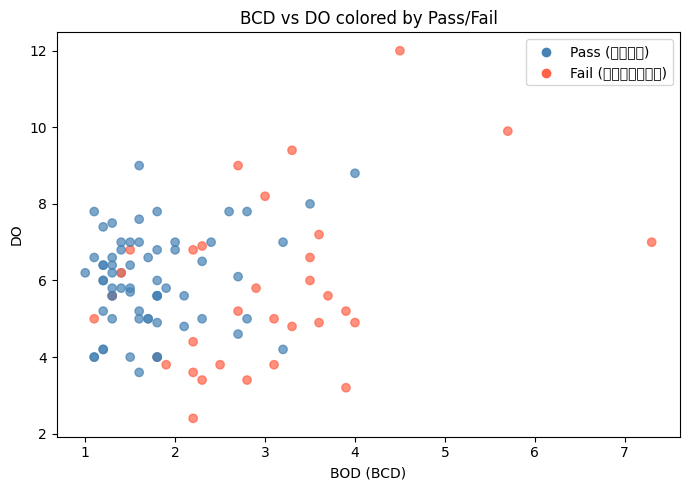

In [16]:
# Scatter plot: BCD vs DO ระบายสีตาม class
colors = []
for val in y:
    if val == 1:
        colors.append('steelblue')
    else:
        colors.append('tomato')

plt.figure(figsize=(7, 5))
plt.scatter(wqi['BCD'], wqi['DO'], c=colors, alpha=0.7)
plt.xlabel('BOD (BCD)')
plt.ylabel('DO')
plt.title('BCD vs DO colored by Pass/Fail')
plt.legend(
    handles=[
        plt.scatter([], [], c='steelblue', label='Pass (ผ่าน)'),
        plt.scatter([], [], c='tomato', label='Fail (ไม่ผ่าน)')
    ]
)
plt.tight_layout()
plt.show()

## Scale และ Split

- **train_test_split**: แบ่งข้อมูลเป็น Train 75% และ Test 25%
  ด้วยชุดข้อมูล ~98 แถว Test set จะมีประมาณ 24–25 แถว → เล็กมาก
  ทำให้ metric แกว่งตาม random_state (จะเห็นชัดใน Phase C)

- **StandardScaler**: fit บน Train set เท่านั้น แล้ว transform ทั้ง Train และ Test
  ห้าม fit บน Test set หรือข้อมูลรวม เพราะจะทำให้ข้อมูล Test "รั่ว" เข้า Train

In [17]:
# แบ่ง Train/Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [18]:
# Scale feature ด้วย StandardScaler — fit เฉพาะ train
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

In [19]:
# สร้างและ fit โมเดล Logistic Regression
clf = LogisticRegression(random_state=42)
clf.fit(X_train_s, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [20]:
# ตรวจสอบ clf.classes_ ก่อนตีความ Coefficient เสมอ
clf.classes_

array([0, 1], dtype=int64)

In [21]:
# ดู Coefficient ของแต่ละ Feature
pd.DataFrame({'feature': ['DO', 'BCD', 'NH3'], 'coef': clf.coef_[0]})

,feature,coef
0,DO,0.351128
1,BCD,-1.010043
2,NH3,-0.717290


## แปลความหมาย Coefficient

จากที่เช็ค `clf.classes_` แล้วพบว่า class 1 = ผ่าน (positive class)
ดังนั้น Coefficient บวก = ดัน probability ไปทาง "ผ่าน"
Coefficient ลบ = ดัน probability ไปทาง "ไม่ผ่าน"

| Feature | ทิศ Coef | ความหมาย |
|---------|----------|-----------|
| DO | บวก | ออกซิเจนละลายน้ำสูง → โอกาสผ่านมากขึ้น (สอดคล้องกับ Boxplot) |
| BCD (BOD) | ลบ | ภาระอินทรีย์สูง → โอกาสไม่ผ่านมากขึ้น (แยกได้แรงที่สุด) |
| NH3 | ลบ | แอมโมเนียสูง → โอกาสไม่ผ่านมากขึ้น (แยกได้อ่อนกว่า) |

เนื่องจากข้อมูลถูก Scale แล้ว ขนาดสัมบูรณ์ของ Coefficient เทียบกันได้คร่าว ๆ
BCD มีค่า |coef| มากกว่า NH3 → สอดคล้องกับ Boxplot ที่เห็น BCD แยกได้ชัดกว่า

**อย่าตีความขนาด Coefficient โดยไม่ Scale** เพราะตัวเลขจะถูก scale ของ feature บิดเบือน

In [22]:
# ทำนายผลบน Test set
y_pred = clf.predict(X_test_s)
y_pred

array([1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 0, 1], dtype=int64)

## PHASE C — Evaluation

### Confusion Matrix คืออะไร?

ตารางเปรียบเทียบผลจริง (Actual) กับผลที่โมเดลทำนาย (Predicted):

|  | ทำนาย: ผ่าน (1) | ทำนาย: ไม่ผ่าน (0) |
|--|----------------|-------------------|
| จริง: ผ่าน (1) | **TP** — True Positive (ทำนายถูก ว่าผ่าน) | **FN** — False Negative (พลาด ว่าผ่านแต่ทำนายว่าไม่ผ่าน) |
| จริง: ไม่ผ่าน (0) | **FP** — False Positive (ทำนายผิด ว่าไม่ผ่านแต่บอกว่าผ่าน) | **TN** — True Negative (ทำนายถูก ว่าไม่ผ่าน) |

- **FP** อันตรายในบริบทน้ำ: บอกว่าน้ำ "ผ่าน" ทั้งที่จริงไม่ผ่าน
- **FN**: ระมัดระวังเกิน บอกว่าไม่ผ่านทั้งที่จริงผ่าน

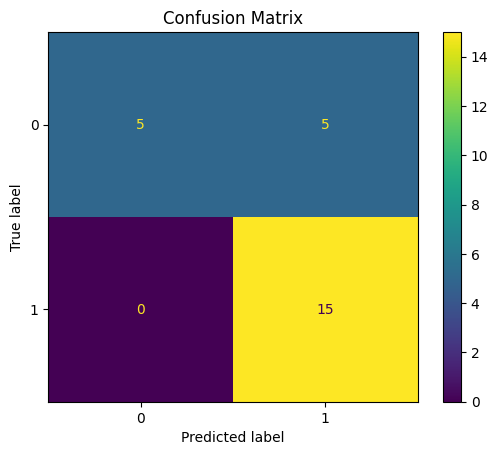

In [23]:
# คำนวณและแสดง Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title('Confusion Matrix')
plt.show()

## Accuracy, Precision และ Recall

$$\text{Accuracy} = \frac{TP + TN}{\text{ทั้งหมด}}$$
→ โมเดลทำนายถูกกี่เปอร์เซ็นต์จากทั้งหมด

$$\text{Precision} = \frac{TP}{TP + FP}$$
→ ในจำนวนที่โมเดลบอกว่า "ผ่าน" ถูกจริงกี่เปอร์เซ็นต์

$$\text{Recall} = \frac{TP}{TP + FN}$$
→ ในจำนวนที่ "ผ่านจริง" โมเดลจับได้กี่เปอร์เซ็นต์

เลือก Metric ตามเป้าหมาย:
- ถ้าเน้นไม่ปล่อยน้ำเสียผ่าน → เน้น **Precision** (ลด FP)
- ถ้าเน้นจับน้ำเสียให้ครบ → เน้น **Recall** (ลด FN)

In [24]:
# แสดง Train และ Test Accuracy เปรียบเทียบกัน
y_pred_train = clf.predict(X_train_s)
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy: ", accuracy_score(y_test, y_pred))

Train Accuracy: 0.821917808219178
Test Accuracy:  0.8


In [25]:
# Classification Report แบบ text
print(classification_report(y_test, y_pred, target_names=['ไม่ผ่าน', 'ผ่าน']))

              precision    recall  f1-score   support

     ไม่ผ่าน       1.00      0.50      0.67        10
        ผ่าน       0.75      1.00      0.86        15

    accuracy                           0.80        25
   macro avg       0.88      0.75      0.76        25
weighted avg       0.85      0.80      0.78        25



In [26]:
# Classification Report แบบ DataFrame พร้อม rename และ transpose
report_df = pd.DataFrame(
    classification_report(y_test, y_pred, output_dict=True)
)
report_df = report_df.rename(columns={'0': 'ไม่ผ่าน', '1': 'ผ่าน'})
report_df.transpose()

,precision,recall,f1-score,support
ไม่ผ่าน,1.000,0.50,0.666667,10.0
ผ่าน,0.750,1.00,0.857143,15.0
accuracy,0.800,0.80,0.800000,0.8
macro avg,0.875,0.75,0.761905,25.0
weighted avg,0.850,0.80,0.780952,25.0


## ทำไม Accuracy เดี่ยวถึงหลอกตาได้?

**ปัญหาที่ 1 — Test set เล็กมาก:**
~98 แถว → Test ประมาณ 24–25 แถว
แถวเดียวที่ทำนายผิดเพิ่มเปลี่ยน Accuracy ได้ 4% ทันที
ดังนั้น random_state ต่างกันจะให้ตัวเลขต่างกัน — ไม่ควรเชื่อตัวเลขทศนิยมเดียว

**ปัญหาที่ 2 — Class ไม่สมดุล:**
ถ้าข้อมูลมี "ผ่าน" 80% และ "ไม่ผ่าน" 20%
โมเดลโง่ที่ทำนาย "ผ่าน" ทุกครั้ง จะได้ Accuracy = 80% โดยไม่ต้องเรียนรู้อะไร

**แนวทาง:** อ่าน Confusion Matrix ประกอบเสมอ
เพราะ Confusion Matrix เผยให้เห็นว่าโมเดล **พลาดด้านไหน** ไม่ใช่แค่ว่าพลาดเยอะแค่ไหน

## แบบฝึกหัด: ลอง random_state อื่น

**คำสั่ง:** เปลี่ยน `random_state` ใน `train_test_split` จาก 42 เป็นตัวเลขอื่น (เช่น 0, 7, 99)
แล้วรัน split → scale → fit → predict → accuracy + confusion matrix ใหม่

**สังเกต:** Accuracy และ Confusion Matrix เปลี่ยนไปหรือไม่? เปลี่ยนมากแค่ไหน?
**อธิบาย:** เหตุใดตัวเลขถึงแกว่ง ทั้งที่ข้อมูลชุดเดิม?

Accuracy (random_state=7): 0.8

              precision    recall  f1-score   support

     ไม่ผ่าน       0.80      0.50      0.62         8
        ผ่าน       0.80      0.94      0.86        17

    accuracy                           0.80        25
   macro avg       0.80      0.72      0.74        25
weighted avg       0.80      0.80      0.79        25



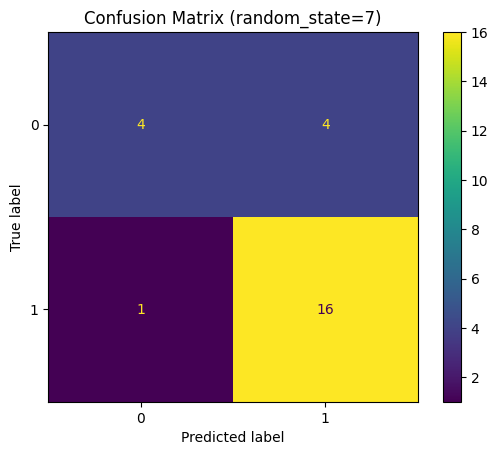

In [27]:
# เฉลย
# ทดสอบด้วย random_state ต่างกัน เพื่อเห็นว่า metric แกว่งเพราะ test set เล็ก
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.25, random_state=7  # เปลี่ยนจาก 42 เป็น 7
)

# scale ใหม่บน split ใหม่ — ต้อง fit scaler บน train ใหม่เสมอ
scaler2 = StandardScaler()
X_train2_s = scaler2.fit_transform(X_train2)
X_test2_s = scaler2.transform(X_test2)

# fit โมเดลใหม่บน split ใหม่
clf2 = LogisticRegression()
clf2.fit(X_train2_s, y_train2)
y_pred2 = clf2.predict(X_test2_s)

print("Accuracy (random_state=7):", accuracy_score(y_test2, y_pred2))
print()
print(classification_report(y_test2, y_pred2, target_names=['ไม่ผ่าน', 'ผ่าน']))

cm2 = confusion_matrix(y_test2, y_pred2)
ConfusionMatrixDisplay(cm2).plot()
plt.title('Confusion Matrix (random_state=7)')
plt.show()

# ตัวเลข Accuracy และ Confusion Matrix เปลี่ยนไปเพราะ test set มีเพียง ~24 แถว
# แต่ละ random_state ดึง "ตัวอย่าง" คนละชุด — แถวเดียวที่เปลี่ยนมือ = Accuracy ขยับ ~4%
# นี่คือเหตุผลที่ไม่ควรสรุปคุณภาพโมเดลจาก random split เดียว

---
## Test Prediction on New Data

ทดลองนำโมเดลที่เทรนแล้วไปพยากรณ์กับข้อมูลใหม่ที่สร้างจากช่วง min/max ของ DO, BCD, NH3

In [28]:
# สร้าง sample ใหม่จากช่วง min/max ของแต่ละ feature
np.random.seed(42)
n_samples = 5

new_wqi = pd.DataFrame({
    col: np.random.uniform(wqi[col].min(), wqi[col].max(), n_samples)
    for col in ['DO', 'BCD', 'NH3']
})
new_wqi

,DO,BCD,NH3
0,5.995585,1.982765,0.021321
1,11.526857,1.365927,0.543450
2,9.427142,6.456910,0.467843
3,8.147121,4.787025,0.126787
4,3.897779,5.460857,0.110004


In [29]:
# Scale ด้วย scaler เดิมที่ fit บน train set แล้ว
new_wqi_scaled = scaler.transform(new_wqi)

In [30]:
# ดู predict_proba (ความน่าจะเป็นของแต่ละ class)
probabilities = clf.predict_proba(new_wqi_scaled)
prob_df = pd.DataFrame(probabilities, columns=['ไม่ผ่าน (0)', 'ผ่าน (1)'])
prob_df

,ไม่ผ่าน (0),ผ่าน (1)
0,0.162097,0.837903
1,0.477809,0.522191
2,0.996372,0.003628
3,0.847023,0.152977
4,0.966927,0.033073


In [31]:
# ทำนาย class
new_pred = clf.predict(new_wqi_scaled)
print("Predicted classes:", new_pred)

Predicted classes: [1 1 0 0 0]


C:\Users\User\AppData\Local\Temp\ipykernel_28492\3746122476.py:12: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3746122476.py:12: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3746122476.py:12: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3746122476.py:12: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3746122476.py:12: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\3746122476.py:12: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.t

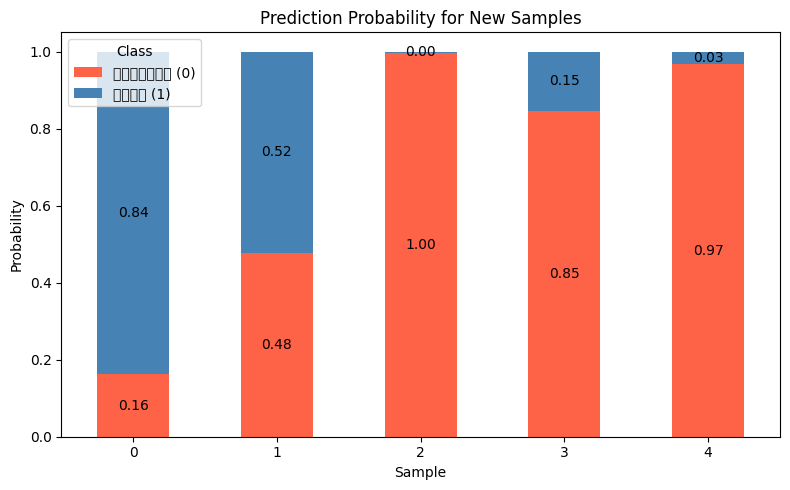

In [32]:
# Stacked bar chart แสดง probability ของแต่ละ sample
plt.figure(figsize=(8, 5))
ax = plt.gca()
prob_df.plot(kind='bar', stacked=True, ax=ax, color=['tomato', 'steelblue'])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='center')
plt.title('Prediction Probability for New Samples')
plt.xlabel('Sample')
plt.ylabel('Probability')
plt.xticks(rotation=0)
plt.legend(title='Class')
plt.tight_layout()
plt.show()

---
## PHASE D — BONUS: Multi-class Classification (ข้ามได้ถ้าเวลาไม่พอ)

ส่วนนี้เป็นการสำรวจเพิ่มเติม ไม่ใช่เนื้อหาหลัก
ใช้ข้อมูลชุดเดิม **ไม่มีไฟล์ใหม่** — เพียงเปลี่ยน label จาก 2 ระดับเป็น 3 ระดับ

## Multi-class: แบ่งน้ำเป็น 3 ระดับ

แทนที่จะถามว่า "ผ่านหรือไม่ผ่าน" เราถามว่า "ดีแค่ไหน?"

| ระดับ | เกณฑ์ WQI | ความหมาย |
|-------|-----------|-----------|
| ดี | ≥ 71 | คุณภาพน้ำดี |
| พอใช้ | 61–70 | ผ่านเกณฑ์ขั้นต่ำ |
| เสื่อมโทรม | < 61 | ต่ำกว่าเกณฑ์ |

Feature ที่ใช้: **DO, BCD, NH3** เหมือนเดิม — X ไม่เปลี่ยน

In [33]:
# ใช้ target_multi เป็น y ใหม่
y_multi = wqi['target_multi']
y_multi.value_counts()

target_multi
พอใช้         40
เสื่อมโทรม    33
ดี            25
Name: count, dtype: int64

In [34]:
# split + scale + เทรน multi-class — workflow เดิม เปลี่ยนแค่ y
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.25, random_state=42
)
scaler_m = StandardScaler()
X_train_m_s = scaler_m.fit_transform(X_train_m)
X_test_m_s = scaler_m.transform(X_test_m)

# max_iter เพิ่มเพราะ 3 class ต้องการรอบ optimization มากกว่า
clf_m = LogisticRegression(max_iter=1000)
clf_m.fit(X_train_m_s, y_train_m)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


C:\Users\User\AppData\Local\Temp\ipykernel_28492\128502761.py:8: UserWarning: Glyph 3604 (\N{THAI CHARACTER DO DEK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\128502761.py:8: UserWarning: Glyph 3637 (\N{THAI CHARACTER SARA II}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\128502761.py:8: UserWarning: Glyph 3614 (\N{THAI CHARACTER PHO PHAN}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\128502761.py:8: UserWarning: Glyph 3629 (\N{THAI CHARACTER O ANG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\128502761.py:8: UserWarning: Glyph 3651 (\N{THAI CHARACTER SARA AI MAIMUAN}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\128502761.py:8: UserWarning: Glyph 3594 (\N{THAI CHARACTER CHO CHANG}) missing from current font.
  plt.tight_layou

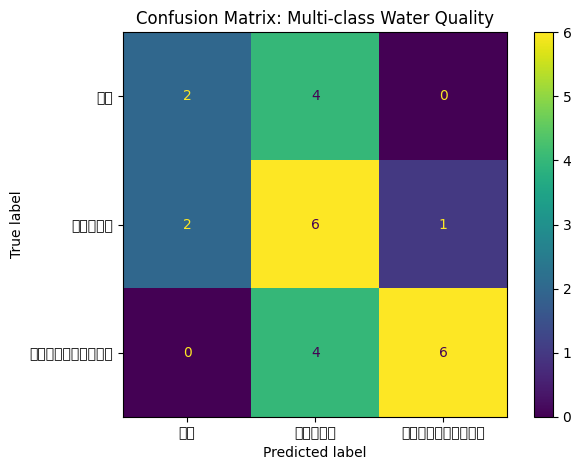

In [35]:
# ทำนาย + แสดง 3x3 Confusion Matrix
y_pred_m = clf_m.predict(X_test_m_s)

labels = ['ดี', 'พอใช้', 'เสื่อมโทรม']
cm_m = confusion_matrix(y_test_m, y_pred_m, labels=labels)
ConfusionMatrixDisplay(cm_m, display_labels=labels).plot()
plt.title('Confusion Matrix: Multi-class Water Quality')
plt.tight_layout()
plt.show()

## สิ่งที่ 3×3 Matrix บอกเรา: Middle-class Absorption

สังเกต Confusion Matrix 3×3:
- กลุ่ม **"ดี"** และ **"เสื่อมโทรม"** มักถูกทำนายเป็น **"พอใช้"**
  → ชั้นกลางดูดซับเพื่อนบ้าน เพราะขอบเขตระหว่าง ordinal class ที่ติดกันไม่ชัดเจน

- Accuracy ≈ 0.60 แต่ตัวเลขนี้ซ่อนไว้ว่า "พอใช้" ถูกทำนายถูกบ่อย
  ขณะที่ "ดี" และ "เสื่อมโทรม" พลาดบ่อยกว่า

- **บทเรียน:** เพิ่มจำนวน class ไม่ได้ทำให้โมเดลฉลาดขึ้น
  ถ้า Feature แยก class เหล่านั้นออกจากกันไม่ได้ คุณภาพ Feature คือเพดานของความแม่น

---
## BONUS: Decision Tree (ข้ามได้ถ้าเวลาไม่พอ)

ทดลองเปลี่ยนโมเดลเป็น Decision Tree บน split เดิม เพื่อเปรียบเทียบผลกับ Logistic Regression

In [36]:
# เทรน Decision Tree บน split เดิม (X_train_s / X_test_s)
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train_s, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [37]:
# Evaluate Decision Tree
y_pred_dt = dt_clf.predict(X_test_s)
print("Decision Tree — Train Accuracy:", accuracy_score(y_train, dt_clf.predict(X_train_s)))
print("Decision Tree — Test Accuracy: ", accuracy_score(y_test, y_pred_dt))
print()
print(classification_report(y_test, y_pred_dt, target_names=['ไม่ผ่าน', 'ผ่าน']))

Decision Tree — Train Accuracy: 1.0
Decision Tree — Test Accuracy:  0.56

              precision    recall  f1-score   support

     ไม่ผ่าน       0.43      0.30      0.35        10
        ผ่าน       0.61      0.73      0.67        15

    accuracy                           0.56        25
   macro avg       0.52      0.52      0.51        25
weighted avg       0.54      0.56      0.54        25



C:\Users\User\AppData\Local\Temp\ipykernel_28492\252113767.py:5: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\252113767.py:5: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\252113767.py:5: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\252113767.py:5: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\252113767.py:5: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_28492\252113767.py:5: UserWarning: Glyph 3609 (\N{THAI CHARACTER NO NU}) missing from current font.
  plt.tight_layout(

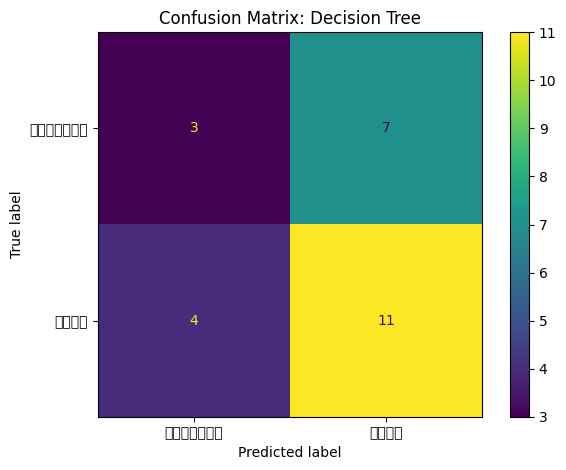

In [38]:
# Confusion Matrix ของ Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=['ไม่ผ่าน', 'ผ่าน']).plot()
plt.title('Confusion Matrix: Decision Tree')
plt.tight_layout()
plt.show()

In [39]:
# ทำนาย new data ด้วย Decision Tree เพื่อเปรียบเทียบกับ Logistic Regression
new_pred_dt = dt_clf.predict(new_wqi_scaled)
print("Logistic Regression prediction:", new_pred)
print("Decision Tree prediction:       ", new_pred_dt)

Logistic Regression prediction: [1 1 0 0 0]
Decision Tree prediction:        [1 0 0 0 0]


---
## Challenge: Model Comparison

เปรียบเทียบ Logistic Regression, Decision Tree, Random Forest และ SVC
บน split เดิม (X_train_s / X_test_s)

In [40]:
# Dictionary ของโมเดลที่จะเปรียบเทียบ
ClassificationModels = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42),
    'SVC':                 SVC(probability=True, random_state=42),
}

In [41]:
# Train ทุกโมเดลบน train set
for name, model in ClassificationModels.items():
    model.fit(X_train_s, y_train)
    print(f"{name} trained.")

Logistic Regression trained.
Decision Tree trained.
Random Forest trained.
SVC trained.


In [42]:
# รวม Accuracy, Precision, Recall, F1-score เป็นตารางเดียว
models_evaluate = pd.DataFrame()
for name, model in ClassificationModels.items():
    pred = model.predict(X_test_s)
    row = pd.DataFrame({
        'Accuracy':  [accuracy_score(y_test, pred)],
        'Precision': [precision_score(y_test, pred, zero_division=0)],
        'Recall':    [recall_score(y_test, pred, zero_division=0)],
        'F1-score':  [f1_score(y_test, pred, zero_division=0)],
    }, index=[name])
    models_evaluate = pd.concat([models_evaluate, row])

models_evaluate

,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.80,0.750000,1.000000,0.857143
Decision Tree,0.56,0.611111,0.733333,0.666667
Random Forest,0.80,0.777778,0.933333,0.848485
SVC,0.92,0.882353,1.000000,0.937500


c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local

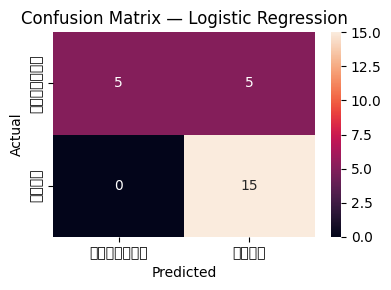

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local

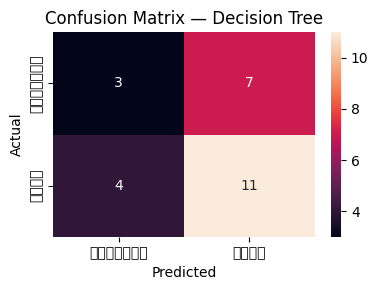

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local

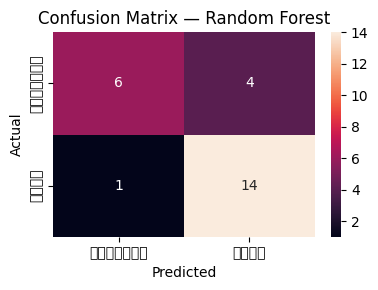

c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3652 (\N{THAI CHARACTER SARA AI MAIMALAI}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3656 (\N{THAI CHARACTER MAI EK}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3612 (\N{THAI CHARACTER PHO PHUNG}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from current font.
  fig.canvas.draw()
c:\Users\User\AppData\Local

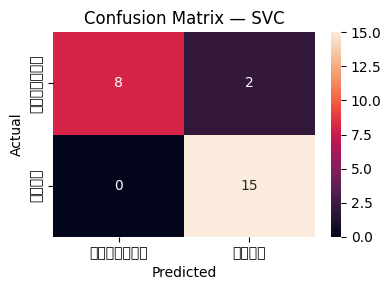

In [43]:
# Confusion Matrix ของแต่ละโมเดล
for name, model in ClassificationModels.items():
    pred = model.predict(X_test_s)
    cm_i = confusion_matrix(y_test, pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_i, annot=True, fmt='d',
                xticklabels=['ไม่ผ่าน', 'ผ่าน'],
                yticklabels=['ไม่ผ่าน', 'ผ่าน'])
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

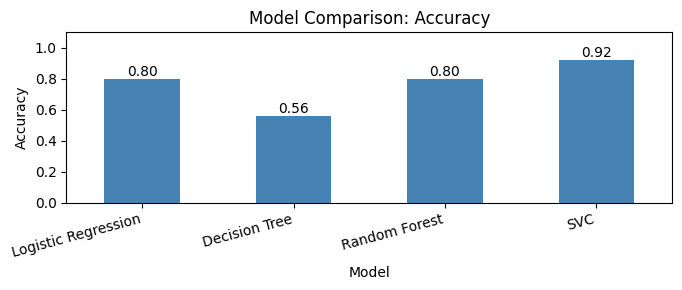

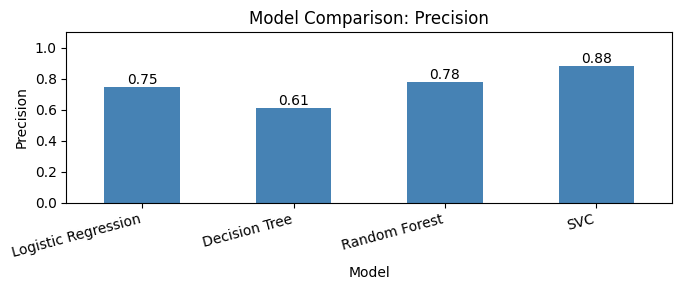

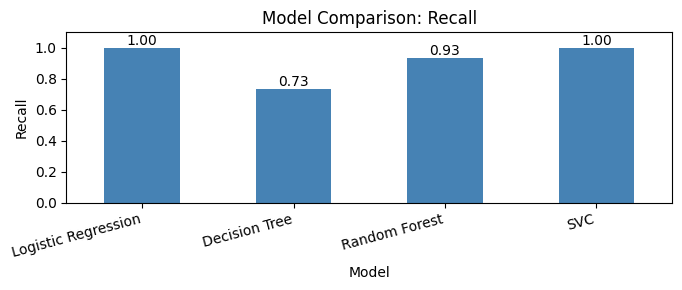

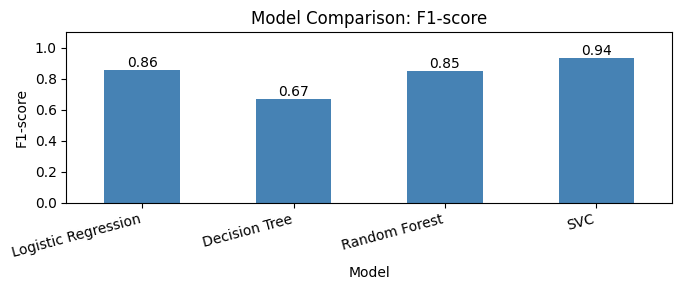

In [44]:
# Bar chart เปรียบเทียบแต่ละ metric ระหว่างโมเดล
for metric in models_evaluate.columns:
    fig, ax = plt.subplots(figsize=(7, 3))
    models_evaluate[metric].plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'Model Comparison: {metric}')
    ax.set_ylabel(metric)
    ax.set_xlabel('Model')
    ax.set_ylim(0, 1.1)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f')
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

## สรุปทั้งวัน

วันนี้เราเห็น **workflow เดียวกัน** ทั้งช่วงเช้าและช่วงบ่าย:
`fit → predict → evaluate` ผ่าน scikit-learn

| ช่วง | งาน | โมเดล | Metric หลัก |
|------|-----|--------|------------|
| เช้า | Regression | LinearRegression | MAE, R² |
| บ่าย | Classification | LogisticRegression | Accuracy, Precision, Recall, Confusion Matrix |

**ก้าวถัดไปที่ยังรออยู่:**
- **Unsupervised Learning / Clustering** — เมื่อไม่มี label ให้เรียน
- **Time Series** — เมื่อข้อมูลเรียงตามเวลา
- **Model Deployment** — เมื่อต้องการนำโมเดลไปใช้งานจริง

ทักษะที่ได้วันนี้คือฐานของทุกขั้นตอนข้างต้น